In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline  

In [3]:
from library.utils import fontstyle, style_map

In [4]:
from collections import defaultdict
import sinter

In [5]:
# Load stim stats

csv_filename = PROJ_ROOT_PATH / "notebooks" / "ler" / "ler_1q2q.csv"

stats = sinter.read_stats_from_csv_files(csv_filename)
print(f"Loaded {len(stats)} simulation tasks.")

Loaded 400 simulation tasks.


In [6]:
from collections import defaultdict
from itertools import count
from scipy.optimize import curve_fit
import numpy as np

def get_required_distance(target_ler, d_vals, ler_vals):
    # print("****")
    # print("Input:", target_ler, d_vals, ler_vals)
    # try to find the nearest distance from the experiment results
    try:
        d_req = next(d for (d, ler) in zip(d_vals, ler_vals) if (ler <= target_ler))
    except:
        # derive the distance with the extrapolation (fitting)
        ## fitting
        def exp_decay(d, A, alpha): # NOTE: Use another fitting function if you want
            return A*np.exp(-alpha*d)
            
        (A_fit, alpha_fit), _ = curve_fit(exp_decay, d_vals, ler_vals)
        # find 
        d_req = next(d for d in count(3,2) if exp_decay(d, A_fit, alpha_fit) <= target_ler)

    return d_req

In [7]:
# input
target_ler = 1e-3

# parsing
grouped = defaultdict(list)
for s in stats:
    md = s.json_metadata
    sq_p = md.get('sq_error')
    tq_p = md.get('tq_error')
    # ms_p = md.get('meas_error')  
    d = md.get('distance')
    ler = float(s.errors / s.shots)
    grouped[(sq_p, tq_p)].append((d, ler))

result = []
for (sq_p, tq_p), val_list in sorted(grouped.items()):
    d_list = [d for (d, _) in val_list]
    ler_list = [ler for (_, ler) in val_list]
    d_req = get_required_distance(target_ler, d_list, ler_list)
    pq_per_lq = 2*(d_req**2)-1
    result.append({"sq_error": sq_p,
                   "tq_error": tq_p, 
                   "d_req": d_req, 
                   "pq_per_lq": pq_per_lq})

# for res in result:
#     print(res)

In [8]:
sq_error = [res['sq_error'] for res in result]
tq_error = [res['tq_error'] for res in result]
pq_per_lq = [res['pq_per_lq'] for res in result]
d = [res['d_req'] for res in result]

NPQ = {
    "HEMT (Baseline)": 778,
    "HEMT-HP-Mn": 874,
    "HEMT-NP-Mn": 1677,
    "HEMT-LP-Mn": 3899,
    "HEMT-LP-YBCO": 3956,
    "SIS-9w-YBCO": 4135,
}

In [9]:
from library.utils import fontstyle, style_map
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

In [10]:
df = pd.DataFrame(result)

In [13]:
# 2. Pivot the data
# This creates a matrix where:
# - Unique 'sq_error' values become the Index (rows)
# - Unique 'tq_error' values become the Columns
# - 'pq_per_lq' values fill the cells
pq_per_lq_matrix = df.pivot(index='sq_error', columns='tq_error', values='pq_per_lq')
# pq_per_lq_matrix = df.pivot(index='sq_error', columns='tq_error', values='d_req')

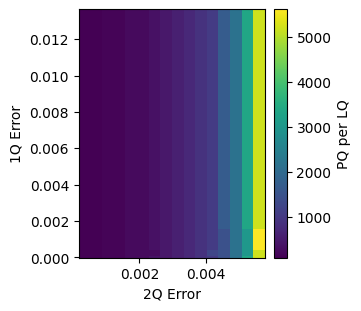

In [14]:
# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)
# pq_per_lq_matrix.columns are the x-coordinates
# pq_per_lq_matrix.index are the y-coordinates
# pq_per_lq_matrix.values is the 2D grid of z-data
im = ax.pcolormesh(pq_per_lq_matrix.columns, 
               pq_per_lq_matrix.index, 
               pq_per_lq_matrix.values, 
               shading='auto', 
               cmap='viridis')

ax.set_xlabel('2Q Error')
ax.set_ylabel('1Q Error')

# Pass the captured 'im' to the colorbar so it knows the data range
# referencing ax=ax ensures it attaches to the correct subplot
fig.colorbar(im, ax=ax, label='PQ per LQ')
plt.show()